In [457]:
import warnings
import sys
from pathlib import Path

import pandas as pd
import plotnine as p9
import matplotlib as mpl
import numpy as np
import yfinance as yf
sys.path.insert(0, str(Path("..").resolve()))
from src.data import load_fx_spot, prepare_bbg_data
from src.plotting import build_all_fx_spot_plots, plot_rebased_equity_indices, plot_cds_data
from sklearn.linear_model import Lasso, LassoCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

warnings.filterwarnings("ignore")
p9.theme_set(p9.theme_gray())
mpl.rcParams["figure.edgecolor"] = "none"
mpl.rcParams["savefig.transparent"] = True

START_DATE = "2021-01-01"
END_DATE = "2026-02-20"
DATA_DIR = Path("../data")

eqy = pd.read_excel(DATA_DIR / "equity_indices.xlsx", parse_dates=["Dates"])
eqy = prepare_bbg_data(eqy, START_DATE, END_DATE)

display(eqy.head())

spx = yf.download("^GSPC", start=START_DATE, end=END_DATE)
ftse = yf.download("^FTSE", start=START_DATE, end=END_DATE)

eqy['SPX Index'] = spx['Close']
eqy['FTSE Index'] = ftse['Close']

eqy


# Mexico, Brazil, South Africa, Japan, Australia, Canada

,MEXBOL Index,IBOV Index,JALSH Index,NKY Index,AS51 Index,SPTSX Index
date,,,,,,
2021-01-04,44703.00,118854.71,60479.42,27258.38,6684.247,17527.77
2021-01-05,44908.12,119376.21,60921.37,27158.63,6681.858,17682.51
2021-01-06,45587.16,119100.08,61857.42,27055.94,6607.054,17828.11
2021-01-07,46188.66,122385.92,63042.88,27490.13,6711.953,18027.57
2021-01-08,46729.30,125076.63,63519.18,28139.03,6757.869,18042.07


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,MEXBOL Index,IBOV Index,JALSH Index,NKY Index,AS51 Index,SPTSX Index,SPX Index,FTSE Index
date,,,,,,,,
2021-01-04,44703.00,118854.71,60479.42,27258.38,6684.247,17527.77,3700.649902,6571.899902
2021-01-05,44908.12,119376.21,60921.37,27158.63,6681.858,17682.51,3726.860107,6612.299805
2021-01-06,45587.16,119100.08,61857.42,27055.94,6607.054,17828.11,3748.139893,6841.899902
2021-01-07,46188.66,122385.92,63042.88,27490.13,6711.953,18027.57,3803.790039,6857.000000
2021-01-08,46729.30,125076.63,63519.18,28139.03,6757.869,18042.07,3824.679932,6873.299805
...,...,...,...,...,...,...,...,...
2026-02-13,71478.81,186464.30,120584.10,56941.97,8917.612,33073.71,6836.169922,10446.400391
2026-02-16,71353.29,186464.30,120988.60,56806.41,8937.095,33073.71,NaN,10473.700195
2026-02-17,71155.69,186464.30,119410.00,56566.49,8958.878,32896.55,6843.220215,10556.200195


In [458]:
eqy_returns = eqy.pct_change().fillna(method='ffill')
eqy_returns

,MEXBOL Index,IBOV Index,JALSH Index,NKY Index,AS51 Index,SPTSX Index,SPX Index,FTSE Index
date,,,,,,,,
2021-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,0.004589,0.004388,0.007307,-0.003659,-0.000357,0.008828,0.007083,0.006147
2021-01-06,0.015121,-0.002313,0.015365,-0.003781,-0.011195,0.008234,0.005710,0.034723
2021-01-07,0.013195,0.027589,0.019164,0.016048,0.015877,0.011188,0.014847,0.002207
2021-01-08,0.011705,0.021985,0.007555,0.023605,0.006841,0.000804,0.005492,0.002377
...,...,...,...,...,...,...,...,...
2026-02-13,0.008334,-0.006935,-0.013332,-0.012107,-0.013925,0.018741,0.000499,0.004230
2026-02-16,-0.001756,0.000000,0.003355,-0.002381,0.002185,0.000000,0.000000,0.002613
2026-02-17,-0.002769,0.000000,-0.013048,-0.004223,0.002437,-0.005357,0.001031,0.007877


In [459]:
vol = pd.read_excel(DATA_DIR / "mkt_volume.xlsx", parse_dates=["Dates"])
vol.index = vol["Dates"]
vol = vol.drop(columns=["Dates"])
vol = vol.loc[START_DATE:END_DATE]
display(vol.head())

,NKY Index,MEXBOL Index,SPTSX Index,JALSH Index,IBOV Index,AS51 Index
Dates,,,,,,
2022-01-03,403887100,56603742,128381580,95189905,1127626100,272408707
2022-01-04,660373200,105053469,269069697,133379134,1149160700,503962435
2022-01-05,786258200,110514283,311252916,133543325,1288369200,472274453
2022-01-06,715910200,145921886,238503466,147162608,1174921000,623918166
2022-01-07,751712100,104193545,201893240,126718301,1173341400,469077119


In [460]:
mex = eqy_returns[['MEXBOL Index', 'SPX Index']]
bra = eqy_returns[['IBOV Index', 'SPX Index']]
saf = eqy_returns[['JALSH Index', 'SPX Index']]
jpn = eqy_returns[['NKY Index', 'SPX Index']]
aus = eqy_returns[['AS51 Index', 'SPX Index']]
can = eqy_returns[['SPTSX Index', 'SPX Index']]
gb = eqy_returns[['FTSE Index', 'SPX Index']]

countries = {
    'Mexico': mex,
    'Brazil': bra,
    'South Africa': saf,
    'Japan': jpn,
    'Australia': aus,
    'Canada': can,
    'UK': gb
}

countries_quantiles = {
    'Mexico': mex,
    'Brazil': bra,
    'South Africa': saf,
    'Japan': jpn,
    'Australia': aus,
    'Canada': can,
    'UK': gb
}

In [461]:
for country, data in countries.items():
    data['Excess Return'] = data.iloc[:, 0] - data['SPX Index']
    # if country != 'UK':  # UK doesn't have SPX Index, so we skip this step for UK
    #     data['Volume'] = vol[data.iloc[:, 0].name]
    #     data['Volume change'] = data['Volume'].pct_change()
    #     data['total Return'] = data.iloc[:, 0] * data['Volume']
    # data['Excess Return_quantiles'] = pd.qcut(data['Excess Return'], q=10, labels=False)
    data['rolling 20 day volatility'] = data['Excess Return'].rolling(window=20).std()
    data['rolling 10 day volatility'] = data['Excess Return'].rolling(window=10).std()
    data['rolling 5 day volatility'] = data['Excess Return'].rolling(window=5).std()
    data['rolling 20 day mean'] = data['Excess Return'].rolling(window=20).mean()
    data['rolling 10 day mean'] = data['Excess Return'].rolling(window=10).mean()
    data['rolling 5 day mean'] = data['Excess Return'].rolling(window=5).mean()
    data['rolling 3 day mean'] = data['Excess Return'].rolling(window=3).mean()
    # data['lagged 1 day excess return'] = data['Excess Return'].shift(1)
    # data['lagged 2 day excess return'] = data['Excess Return'].shift(2)
    # data['lagged 3 day excess return'] = data['Excess Return'].shift(3)
    # data['lagged 4 day excess return'] = data['Excess Return'].shift(4)
    # data['lagged 5 day excess return'] = data['Excess Return'].shift(5)
    print(f"{country} - Excess Return and Rolling Statistics:")
    display(data.head())

    # countries_quantiles[country] = data[data['Excess Return_quantiles'] == 9]
    # display(countries_quantiles[country].head())

Mexico - Excess Return and Rolling Statistics:


,MEXBOL Index,SPX Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean
date,,,,,,,,,,
2021-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,0.004589,0.007083,-0.002494,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,0.015121,0.005710,0.009411,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07,0.013195,0.014847,-0.001653,NaN,NaN,NaN,NaN,NaN,NaN,0.001755
2021-01-08,0.011705,0.005492,0.006213,NaN,NaN,NaN,NaN,NaN,NaN,0.004657


Brazil - Excess Return and Rolling Statistics:


,IBOV Index,SPX Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean
date,,,,,,,,,,
2021-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,0.004388,0.007083,-0.002695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,-0.002313,0.005710,-0.008023,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07,0.027589,0.014847,0.012741,NaN,NaN,NaN,NaN,NaN,NaN,0.000675
2021-01-08,0.021985,0.005492,0.016494,NaN,NaN,NaN,NaN,NaN,NaN,0.007071


South Africa - Excess Return and Rolling Statistics:


...

,AS51 Index,SPX Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean
date,,,,,,,,,,
2021-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,-0.000357,0.007083,-0.007440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,-0.011195,0.005710,-0.016905,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07,0.015877,0.014847,0.001029,NaN,NaN,NaN,NaN,NaN,NaN,-0.007772
2021-01-08,0.006841,0.005492,0.001349,NaN,NaN,NaN,NaN,NaN,NaN,-0.004842


Canada - Excess Return and Rolling Statistics:


,SPTSX Index,SPX Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean
date,,,,,,,,,,
2021-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,0.008828,0.007083,0.001746,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,0.008234,0.005710,0.002524,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07,0.011188,0.014847,-0.003659,NaN,NaN,NaN,NaN,NaN,NaN,0.000204
2021-01-08,0.000804,0.005492,-0.004688,NaN,NaN,NaN,NaN,NaN,NaN,-0.001941


UK - Excess Return and Rolling Statistics:


,FTSE Index,SPX Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean
date,,,,,,,,,,
2021-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,0.006147,0.007083,-0.000935,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,0.034723,0.005710,0.029013,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07,0.002207,0.014847,-0.012640,NaN,NaN,NaN,NaN,NaN,NaN,0.005146
2021-01-08,0.002377,0.005492,-0.003115,NaN,NaN,NaN,NaN,NaN,NaN,0.004419


In [462]:
residuals = pd.read_csv(DATA_DIR / "stage1_residuals.csv").set_index('date')
country_residuals = {}
country_residuals['Australia'] = residuals['AUD']
country_residuals['Canada'] = residuals['CAD']
country_residuals['Japan'] = residuals['JPY']
country_residuals['Mexico'] = residuals['MXN']
country_residuals['South Africa'] = residuals['ZAR']
country_residuals['UK'] = residuals['GBP']


In [463]:
fx_returns = pd.read_csv(DATA_DIR / "fx_returns_data.csv").set_index('date')
country_fx_returns = {}
country_fx_returns['Australia'] = fx_returns['AUD']
country_fx_returns['Canada'] = fx_returns['CAD']
country_fx_returns['Japan'] = fx_returns['JPY']
country_fx_returns['Mexico'] = fx_returns['MXN']
country_fx_returns['South Africa'] = fx_returns['ZAR']
country_fx_returns['UK'] = fx_returns['GBP']    

In [464]:

def evaluate_signal(predictions, y_test, top_pcts=[.1]):
    predictions = pd.Series(predictions, index=y_test.index)
    y_test = pd.Series(y_test)
    directional_accuracy = np.mean(
        np.sign(predictions) == np.sign(y_test)
    )
    print("Overall Directional Accuracy:", directional_accuracy)
    strong_accuracies = []
    for top_pct in top_pcts:
        threshold = predictions.abs().quantile(1 - top_pct)
        # print(f"Threshold for top {int(top_pct*100)}% signals: {threshold:.4f}")
        strong_mask = predictions.abs() >= threshold
        strong_directional_accuracy = np.mean(
            np.sign(predictions[strong_mask]) == np.sign(y_test[strong_mask])
        )
        print(f"Top {int(top_pct*100)}% Strongest Signals:")
        print("Directional Accuracy:", strong_directional_accuracy)
        strong_accuracies.append((top_pct, strong_directional_accuracy))
    return {
        "overall_direction": directional_accuracy,
        "strong_direction": strong_directional_accuracy
    }, strong_accuracies


def ols_regression(X_train, y_train, X_test, y_test):
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    display(pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': lr.coef_
    }))
    train_predictions = lr.predict(X_train)
    _, strong_accuracies_train = evaluate_signal(train_predictions, y_train)
    train_r2 = lr.score(X_train, y_train)
    predictions = lr.predict(X_test)
    df = pd.DataFrame({
        'Actual': y_test,
        'Predicted': predictions
    })
    display(df)
    print(f"R^2 Score: {lr.score(X_test, y_test)}")
    _, strong_accuracies_test = evaluate_signal(predictions, y_test)
    return predictions, lr, df[['Actual']], train_r2, lr.score(X_test, y_test), strong_accuracies_train, strong_accuracies_test



def standard_lasso_cv(X_train, y_train, X_test, y_test, alphas=None):
    
    if alphas is None:
        alphas = np.logspace(-5, 1, 100)
    # print(alphas)
    tscv = TimeSeriesSplit(n_splits=5)
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", LassoCV(
            alphas=alphas,
            cv=tscv,
            fit_intercept=True,
            max_iter=10000
        ))
    ])
    model.fit(X_train, y_train)
    lasso = model.named_steps["lasso"]
    print(f"Chosen alpha: {lasso.alpha_}")
    display(pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': lasso.coef_
    }))
    train_predictions = model.predict(X_train)
    train_r2 = model.score(X_train, y_train)
    _, strong_accuracies_train = evaluate_signal(train_predictions, y_train)
    predictions = model.predict(X_test)
    display(pd.DataFrame({
        'Actual': y_test,
        'Predicted': predictions
    }))
    print(f"R^2 Score: {model.score(X_test, y_test)}")
    _, strong_accuracies_test = evaluate_signal(predictions, y_test)
    return predictions, model, y_test, train_r2, model.score(X_test, y_test), strong_accuracies_train, strong_accuracies_test

In [465]:


def random_forest_model(X_train, y_train, X_test, y_test):

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=4,      # keep shallow to prevent overfit
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)
    # print("Train R²:", rf.score(X_train, y_train))
    # train_predictions = rf.predict(X_train)
    # evaluate_signal(train_predictions, y_train)
    #print("Test R²:", rf.score(X_test, y_test))
    #predictions = rf.predict(X_test)
    # evaluate_signal(predictions, y_test)
    print("\nImportance-Based Feature Selection:")
    importances = pd.Series(
        rf.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)
    # print("\nFeature Importances:")
    # display(importances)
    top_features = importances.index[:int(len(importances)/2)]

    X_train_reduced = X_train[top_features]
    X_test_reduced  = X_test[top_features]

    rf_reduced = RandomForestRegressor(
        n_estimators=300,
        max_depth=3,
        min_samples_leaf=15,
        random_state=42,
        n_jobs=-1
    )

    rf_reduced.fit(X_train_reduced, y_train)
    train_predictions = rf_reduced.predict(X_train_reduced)
    train_r2 = rf_reduced.score(X_train_reduced, y_train)
    print("Training Data:")
    print("Train R² (Reduced):", train_r2)
    dic, strong_accuracies_train = evaluate_signal(train_predictions, y_train)
    print()
    print("Testing Data:")
    predictions_reduced = rf_reduced.predict(X_test_reduced)
    test_r2 = rf_reduced.score(X_test_reduced, y_test)
    print("Reduced Test R²:", test_r2)
    dic, strong_accuracies_test = evaluate_signal(predictions_reduced, y_test)
    #evaluate_signal(predictions_reduced, y_test)
    return predictions_reduced, rf_reduced, y_test, train_r2, test_r2, strong_accuracies_train, strong_accuracies_test


def gradient_boost_model(X_train, y_train, X_test, y_test):

    gbr = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.7,
        random_state=42
    )

    gbr.fit(X_train, y_train)
    print("Train R²:", gbr.score(X_train, y_train))
    print("Test R²:", gbr.score(X_test, y_test))

    predictions = gbr.predict(X_test)
    evaluate_signal(predictions, y_test)
    return predictions, gbr

In [466]:
def expanding_oos_rf(X, y, split_date):

    X_train_full = X.loc[:split_date]
    y_train_full = y.loc[:split_date]

    X_test_full = X.loc[split_date:]
    y_test_full = y.loc[split_date:]

    predictions = []
    actuals = []
    dates = []

    for date in X_test_full.index:

        X_train = X.loc[:date].iloc[:-1]
        y_train = y.loc[:date].iloc[:-1]

        X_test = X.loc[[date]]
        y_actual = y.loc[date]

        rf = RandomForestRegressor(
            n_estimators=300,
            max_depth=3,
            min_samples_leaf=15,
            random_state=42,
            n_jobs=-1
        )

        rf.fit(X_train, y_train)

        pred = rf.predict(X_test)[0]

        predictions.append(pred)
        actuals.append(y_actual)
        dates.append(date)

    return pd.Series(predictions, index=dates), pd.Series(actuals, index=dates)

# OLS:

In [467]:
preds = pd.DataFrame()
train_r2s = {}
test_r2s = {}
train_accuracies = {}
test_accuracies = {}

for country, data in countries.items():
    if country not in country_residuals:
        print(f"Residuals for {country} not found. Skipping regression.")
        continue
    X_train = countries[country]['2022-01-01':'2024-09-30']
    y_train = country_residuals[country]['2022-01-01':'2024-09-30'].shift(-1).dropna()  # Shift to align with next day's return
    X_train = X_train.copy()
    y_train = y_train.copy()
    X_train.index = pd.to_datetime(X_train.index)
    y_train.index = pd.to_datetime(y_train.index)
    df_train = pd.concat([X_train, y_train], axis=1).dropna()
    df_train.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features

    X_test = countries[country]['2025-01-01':'2026-01-01']
    y_test = country_residuals[country]['2025-01-01':'2026-01-01'].shift(-1).dropna()  # Shift to align with next day's return
    X_test = X_test.copy()
    y_test = y_test.copy()
    X_test.index = pd.to_datetime(X_test.index)
    y_test.index = pd.to_datetime(y_test.index)
    df_test = pd.concat([X_test, y_test], axis=1).dropna()
    df_test.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features

    model_preds, model, ys, trains_r2, test_r2, strong_acc_train, strong_acc_test = ols_regression(df_train[['Excess Return']], df_train.iloc[:, -1], df_test[['Excess Return']], df_test.iloc[:, -1])
    display(ys)

    if country == 'Mexico':
        preds.index = ys.index
    preds[country] = model_preds
    train_r2s[country] = trains_r2
    test_r2s[country] = test_r2
    train_accuracies[country] = strong_acc_train
    test_accuracies[country] = strong_acc_test


,Feature,Coefficient
0,Excess Return,0.064316


Overall Directional Accuracy: 0.5106382978723404
Top 10% Strongest Signals:
Directional Accuracy: 0.5757575757575758


,Actual,Predicted
date,,
2025-01-03,0.009626,-0.001847
2025-01-06,-0.000437,0.000356
2025-01-07,0.002993,0.001491
2025-01-08,-0.003733,-0.000672
2025-01-09,-0.004295,0.000233
...,...,...
2025-12-22,0.000376,0.000409
2025-12-23,-0.002029,0.000526
2025-12-24,-0.002433,-0.000179


R^2 Score: -0.042828184674924774
Overall Directional Accuracy: 0.5294117647058824
Top 10% Strongest Signals:
Directional Accuracy: 0.5833333333333334


,Actual
date,
2025-01-03,0.009626
2025-01-06,-0.000437
2025-01-07,0.002993
2025-01-08,-0.003733
2025-01-09,-0.004295
...,...
2025-12-22,0.000376
2025-12-23,-0.002029
2025-12-24,-0.002433


...

,Feature,Coefficient
0,Excess Return,-0.00086


Overall Directional Accuracy: 0.5243161094224924
Top 10% Strongest Signals:
Directional Accuracy: 0.4696969696969697


,Actual,Predicted
date,,
2025-01-03,0.000526,0.000020
2025-01-06,-0.000357,0.000007
2025-01-07,-0.005235,-0.000004
2025-01-08,-0.002189,0.000006
2025-01-09,-0.001178,-0.000002
...,...,...
2025-12-22,-0.000981,0.000013
2025-12-23,-0.000477,0.000007
2025-12-24,0.001153,0.000010


R^2 Score: -0.0007077203447503067
Overall Directional Accuracy: 0.5126050420168067
Top 10% Strongest Signals:
Directional Accuracy: 0.5


,Actual
date,
2025-01-03,0.000526
2025-01-06,-0.000357
2025-01-07,-0.005235
2025-01-08,-0.002189
2025-01-09,-0.001178
...,...
2025-12-22,-0.000981
2025-12-23,-0.000477
2025-12-24,0.001153


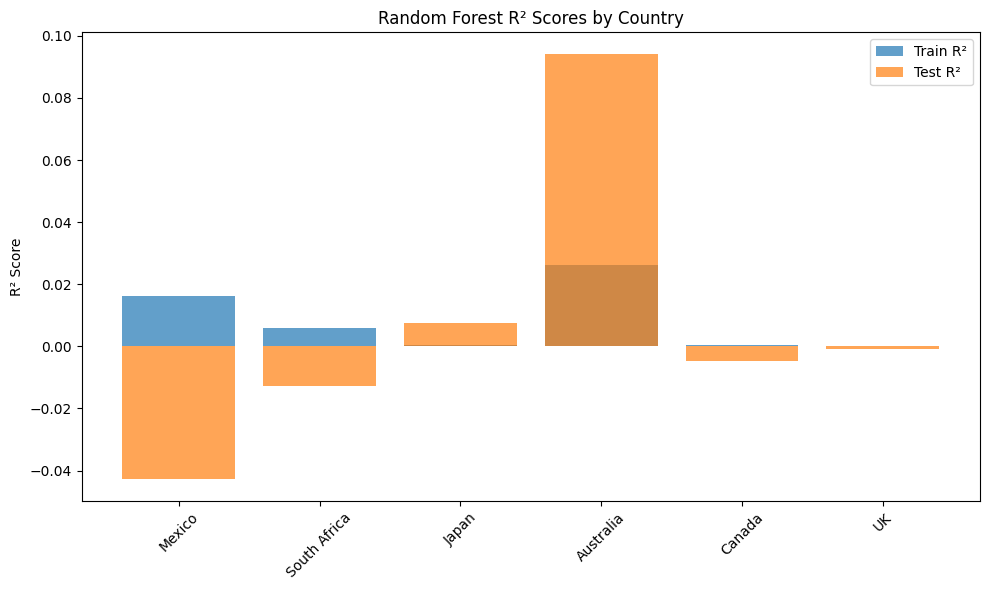

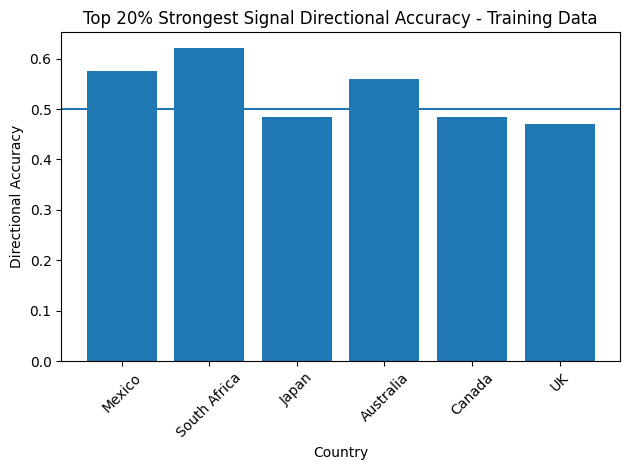

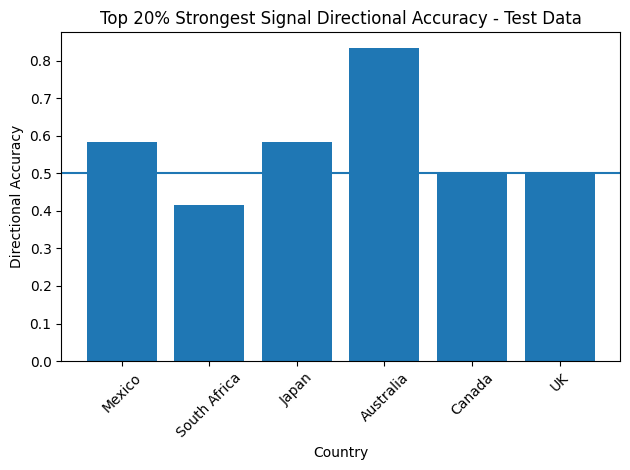

In [468]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(train_r2s.keys(), train_r2s.values(), alpha=0.7, label='Train R²')
plt.bar(test_r2s.keys(), test_r2s.values(), alpha=0.7, label='Test R²')
plt.ylabel('R² Score')
plt.title('Random Forest R² Scores by Country')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Extract countries and second value from tuple
countries2 = list(train_accuracies.keys())
values = [v[0][1] for v in train_accuracies.values()]

# Create bar plot
plt.figure()
plt.bar(countries2, values)

plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 20% Strongest Signal Directional Accuracy - Training Data")
plt.xticks(rotation=45)

# Optional benchmark line at 0.5
plt.axhline(0.5)

plt.tight_layout()
plt.show()

# Extract countries and second value from tuple
countries2 = list(test_accuracies.keys())
values = [v[0][1] for v in test_accuracies.values()]

# Create bar plot
plt.figure()
plt.bar(countries2, values)

plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 20% Strongest Signal Directional Accuracy - Test Data")
plt.xticks(rotation=45)

# Optional benchmark line at 0.5
plt.axhline(0.5)

plt.tight_layout()
plt.show()

# Lasso

In [469]:
preds = pd.DataFrame()
train_r2s = {}
test_r2s = {}
train_accuracies = {}
test_accuracies = {}

for country, data in countries.items():
    if country not in country_residuals:
        print(f"Residuals for {country} not found. Skipping regression.")
        continue
    X_train = countries[country]['2022-01-01':'2024-09-30']
    y_train = country_fx_returns[country]['2022-01-01':'2024-09-30'].shift(-1).dropna()  # Shift to align with next day's return
    X_train = X_train.copy()
    y_train = y_train.copy()
    X_train.index = pd.to_datetime(X_train.index)
    y_train.index = pd.to_datetime(y_train.index)
    df_train = pd.concat([X_train, y_train], axis=1).dropna()
    df_train.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features
    # print(f"{country} - Training Data for Lasso Regression:")
    # display(df_train)
    X_test = countries[country]['2025-01-01':'2026-01-01']
    y_test = country_fx_returns[country]['2025-01-01':'2026-01-01'].shift(-1).dropna()  # Shift to align with next day's return
    X_test = X_test.copy()
    y_test = y_test.copy()
    X_test.index = pd.to_datetime(X_test.index)
    y_test.index = pd.to_datetime(y_test.index)
    df_test = pd.concat([X_test, y_test], axis=1).dropna()
    df_test.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features

    print(f"\nLasso Regression Results for {country}:")
    
    Model_pred, model, ys, trains_r2, test_r2, strong_acc_train, strong_acc_test = standard_lasso_cv(df_train.iloc[:, :-1], df_train.iloc[:, -1], df_test.iloc[:, :-1], df_test.iloc[:, -1])

    if country == 'Mexico':
        preds.index = ys.index
    preds[country] = model_preds
    train_r2s[country] = trains_r2
    test_r2s[country] = test_r2
    train_accuracies[country] = strong_acc_train
    test_accuracies[country] = strong_acc_test

    


Lasso Regression Results for Mexico:
Chosen alpha: 0.0004977023564332114


,Feature,Coefficient
0,MEXBOL Index,0.001169
1,Excess Return,0.000000
2,rolling 20 day volatility,0.000000
3,rolling 10 day volatility,0.000000
4,rolling 5 day volatility,-0.000000
5,rolling 20 day mean,-0.000000
6,rolling 10 day mean,0.000000
7,rolling 5 day mean,0.000000
8,rolling 3 day mean,-0.000000


Overall Directional Accuracy: 0.5851063829787234
Top 10% Strongest Signals:
Directional Accuracy: 0.7878787878787878


,Actual,Predicted
date,,
2025-01-03,0.018608,-0.001410
2025-01-06,-0.001943,0.001814
2025-01-07,-0.001865,0.001934
2025-01-08,-0.006050,-0.000553
2025-01-09,-0.009693,0.000930
...,...,...
2025-12-22,0.003958,0.002019
2025-12-23,0.000452,0.002011
2025-12-24,-0.002700,0.000553


R^2 Score: 0.0071554461174132555
Overall Directional Accuracy: 0.5168067226890757
Top 10% Strongest Signals:
Directional Accuracy: 0.5
Residuals for Brazil not found. Skipping regression.

Lasso Regression Results for South Africa:
Chosen alpha: 0.0013219411484660286


...

R^2 Score: -0.006703368219129313
Overall Directional Accuracy: 0.5042016806722689
Top 10% Strongest Signals:
Directional Accuracy: 0.5042016806722689

Lasso Regression Results for UK:
Chosen alpha: 0.0004977023564332114


,Feature,Coefficient
0,FTSE Index,0.000111
1,Excess Return,-0.000032
2,rolling 20 day volatility,-0.000000
3,rolling 10 day volatility,-0.000000
4,rolling 5 day volatility,-0.000000
5,rolling 20 day mean,-0.000000
6,rolling 10 day mean,-0.000000
7,rolling 5 day mean,-0.000000
8,rolling 3 day mean,-0.000071


Overall Directional Accuracy: 0.560790273556231
Top 10% Strongest Signals:
Directional Accuracy: 0.5909090909090909


,Actual,Predicted
date,,
2025-01-03,0.009084,0.000118
2025-01-06,-0.002291,0.000188
2025-01-07,-0.010512,0.000111
2025-01-08,-0.004923,0.000091
2025-01-09,-0.006993,0.000122
...,...,...
2025-12-22,0.002229,0.000155
2025-12-23,0.001632,0.000212
2025-12-24,0.000521,0.000173


R^2 Score: 0.004167866925562036
Overall Directional Accuracy: 0.542016806722689
Top 10% Strongest Signals:
Directional Accuracy: 0.7083333333333334


# Random Forest 

In [470]:
preds = pd.DataFrame()
train_r2s = {}
test_r2s = {}
train_accuracies = {}
test_accuracies = {}

for country, data in countries.items():
    if country not in country_residuals:
        print(f"Residuals for {country} not found. Skipping regression.")
        continue
    X_train = countries[country]['2022-01-01':'2024-09-30']
    y_train = country_residuals[country]['2022-01-01':'2024-09-30'].shift(-1).dropna()  # Shift to align with next day's return
    X_train = X_train.copy()
    y_train = y_train.copy()
    X_train.index = pd.to_datetime(X_train.index)
    y_train.index = pd.to_datetime(y_train.index)
    df_train = pd.concat([X_train, y_train], axis=1).dropna()

    X_test = countries[country]['2025-01-01':'2026-01-01']
    y_test = country_residuals[country]['2025-01-01':'2026-01-01'].shift(-1).dropna()  # Shift to align with next day's return
    X_test = X_test.copy()
    y_test = y_test.copy()
    X_test.index = pd.to_datetime(X_test.index)
    y_test.index = pd.to_datetime(y_test.index)
    df_test = pd.concat([X_test, y_test], axis=1).dropna()
    
    print(f"\nRandom Forest Regression Results for {country}:")
    rf_predictions, rf_model_instance ,ys, train_r2, test_r2, strong_acc_train, strong_acc_test= random_forest_model(df_train.iloc[:, :-1], df_train.iloc[:, -1], df_test.iloc[:, :-1], df_test.iloc[:, -1])
    if country == 'Mexico':
        preds.index = ys.index
    preds[country] = rf_predictions
    train_r2s[country] = train_r2
    test_r2s[country] = test_r2
    train_accuracies[country] = strong_acc_train
    test_accuracies[country] = strong_acc_test
    
    


Random Forest Regression Results for Mexico:

Importance-Based Feature Selection:
Training Data:
Train R² (Reduced): 0.09864172295949647
Overall Directional Accuracy: 0.6003039513677811
Top 10% Strongest Signals:
Directional Accuracy: 0.7878787878787878

Testing Data:
Reduced Test R²: -0.02460662263719371
Overall Directional Accuracy: 0.5
Top 10% Strongest Signals:
Directional Accuracy: 0.625
Residuals for Brazil not found. Skipping regression.

Random Forest Regression Results for South Africa:

Importance-Based Feature Selection:
Training Data:
Train R² (Reduced): 0.0827464699101409
Overall Directional Accuracy: 0.6322188449848024
Top 10% Strongest Signals:
Directional Accuracy: 0.8181818181818182

Testing Data:
Reduced Test R²: -0.011089868056172847
Overall Directional Accuracy: 0.5168067226890757
Top 10% Strongest Signals:
Directional Accuracy: 0.5833333333333334

Random Forest Regression Results for Japan:

Importance-Based Feature Selection:
Training Data:
Train R² (Reduced): 0.

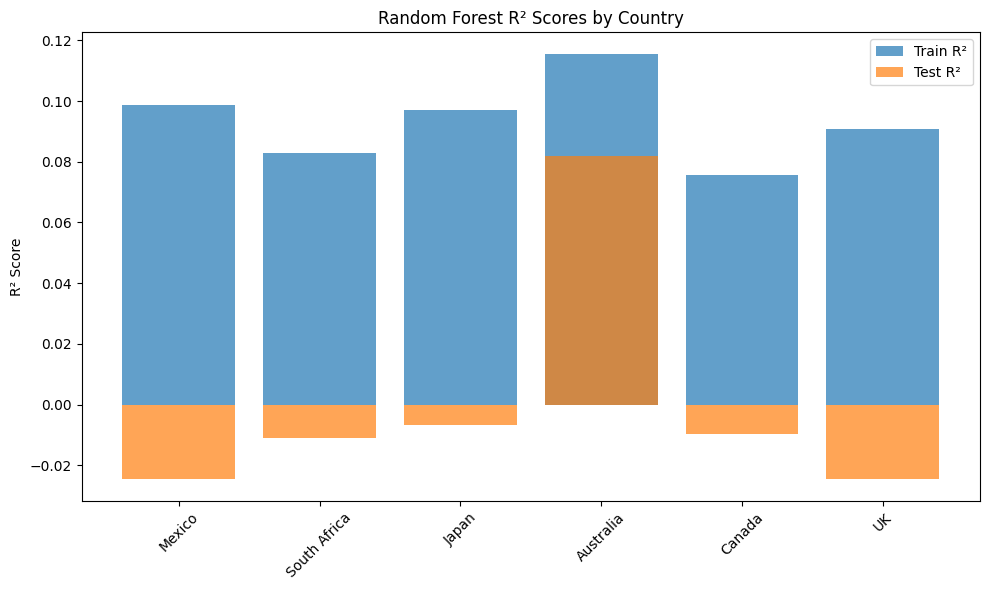

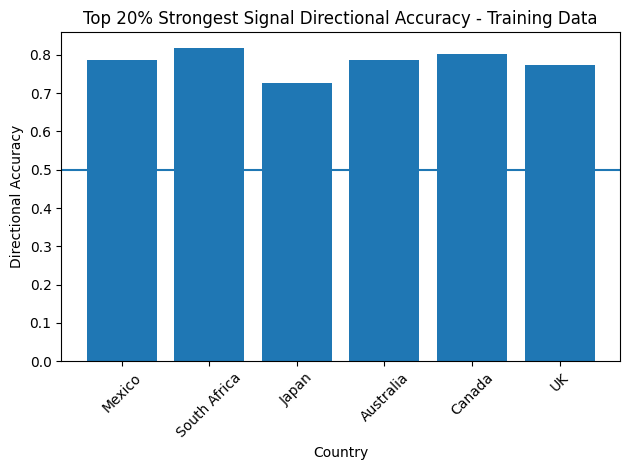

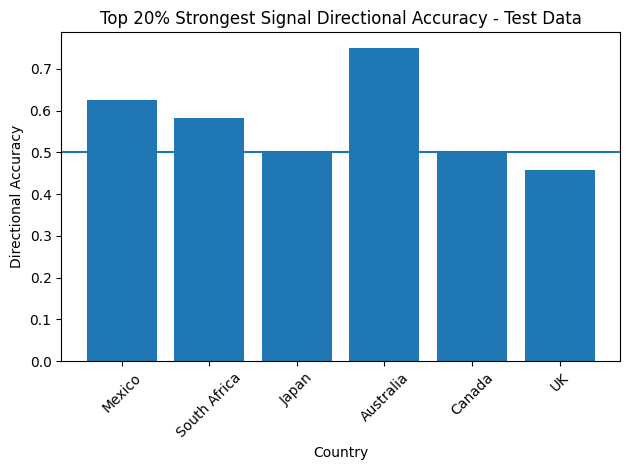

In [471]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(train_r2s.keys(), train_r2s.values(), alpha=0.7, label='Train R²')
plt.bar(test_r2s.keys(), test_r2s.values(), alpha=0.7, label='Test R²')
plt.ylabel('R² Score')
plt.title('Random Forest R² Scores by Country')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Extract countries and second value from tuple
countries2 = list(train_accuracies.keys())
values = [v[0][1] for v in train_accuracies.values()]

# Create bar plot
plt.figure()
plt.bar(countries2, values)

plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 20% Strongest Signal Directional Accuracy - Training Data")
plt.xticks(rotation=45)

# Optional benchmark line at 0.5
plt.axhline(0.5)

plt.tight_layout()
plt.show()

# Extract countries and second value from tuple
countries2 = list(test_accuracies.keys())
values = [v[0][1] for v in test_accuracies.values()]

# Create bar plot
plt.figure()
plt.bar(countries2, values)

plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 20% Strongest Signal Directional Accuracy - Test Data")
plt.xticks(rotation=45)

# Optional benchmark line at 0.5
plt.axhline(0.5)

plt.tight_layout()
plt.show()

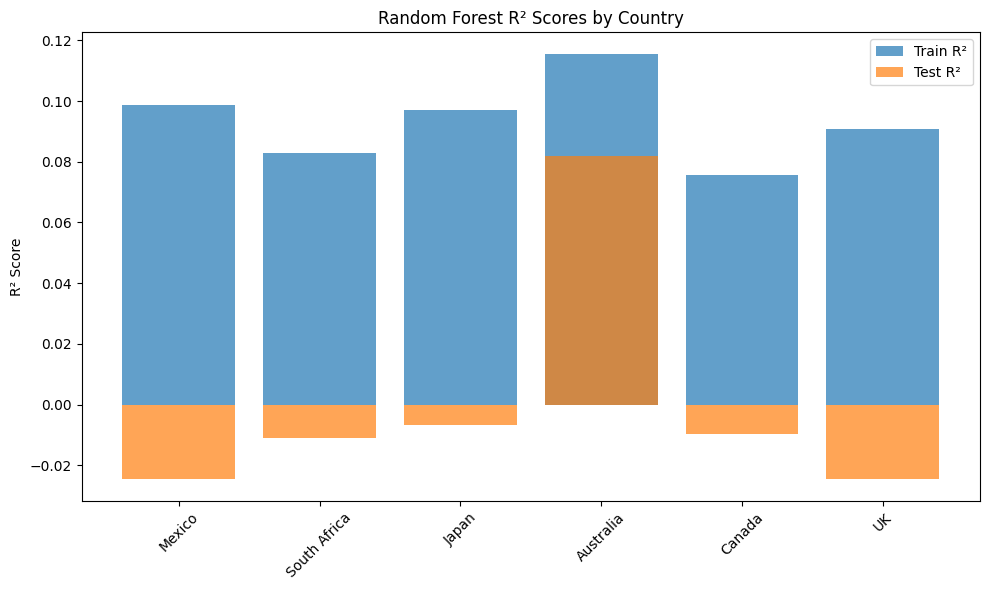

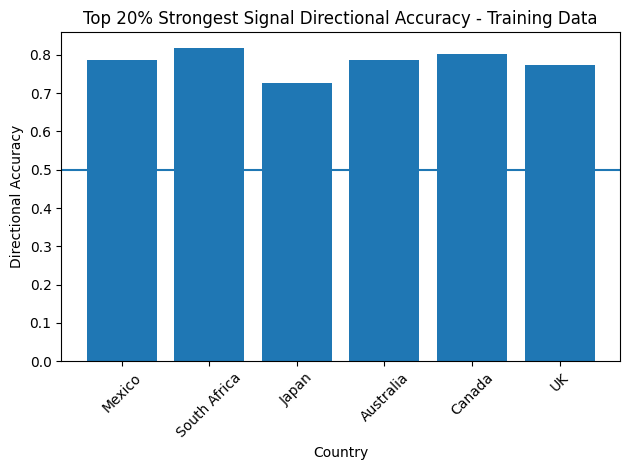

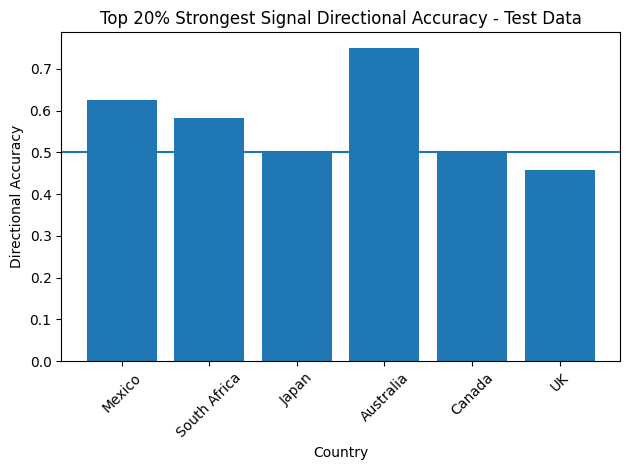

In [472]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(train_r2s.keys(), train_r2s.values(), alpha=0.7, label='Train R²')
plt.bar(test_r2s.keys(), test_r2s.values(), alpha=0.7, label='Test R²')
plt.ylabel('R² Score')
plt.title('Random Forest R² Scores by Country')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Extract countries and second value from tuple
countries2 = list(train_accuracies.keys())
values = [v[0][1] for v in train_accuracies.values()]

# Create bar plot
plt.figure()
plt.bar(countries2, values)

plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 20% Strongest Signal Directional Accuracy - Training Data")
plt.xticks(rotation=45)

# Optional benchmark line at 0.5
plt.axhline(0.5)

plt.tight_layout()
plt.show()

# Extract countries and second value from tuple
countries2 = list(test_accuracies.keys())
values = [v[0][1] for v in test_accuracies.values()]

# Create bar plot
plt.figure()
plt.bar(countries2, values)

plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 20% Strongest Signal Directional Accuracy - Test Data")
plt.xticks(rotation=45)

# Optional benchmark line at 0.5
plt.axhline(0.5)

plt.tight_layout()
plt.show()

# Random Forest - drop SPY

In [473]:
preds = pd.DataFrame()
train_r2s = {}
test_r2s = {}
train_accuracies = {}
test_accuracies = {}

for country, data in countries.items():
    if country not in country_residuals:
        print(f"Residuals for {country} not found. Skipping regression.")
        continue
    X_train = countries[country]['2022-01-01':'2024-09-30']
    y_train = country_residuals[country]['2022-01-01':'2024-09-30'].shift(-1).dropna()  # Shift to align with next day's return
    X_train = X_train.copy()
    y_train = y_train.copy()
    X_train.index = pd.to_datetime(X_train.index)
    y_train.index = pd.to_datetime(y_train.index)
    df_train = pd.concat([X_train, y_train], axis=1).dropna()
    df_train.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features
    

    X_test = countries[country]['2025-01-01':'2026-01-01']
    y_test = country_residuals[country]['2025-01-01':'2026-01-01'].shift(-1).dropna()  # Shift to align with next day's return
    X_test = X_test.copy()
    y_test = y_test.copy()
    X_test.index = pd.to_datetime(X_test.index)
    y_test.index = pd.to_datetime(y_test.index)
    df_test = pd.concat([X_test, y_test], axis=1).dropna()
    df_test.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features

    print(f"\nRandom Forest Regression Results for {country}:")
    rf_predictions, rf_model_instance ,ys, train_r2, test_r2, strong_acc_train, strong_acc_test= random_forest_model(df_train.iloc[:, :-1], df_train.iloc[:, -1], df_test.iloc[:, :-1], df_test.iloc[:, -1])
    if country == 'Mexico':
        preds.index = ys.index
    preds[country] = rf_predictions
    train_r2s[country] = train_r2
    test_r2s[country] = test_r2
    train_accuracies[country] = strong_acc_train
    test_accuracies[country] = strong_acc_test

    


Random Forest Regression Results for Mexico:

Importance-Based Feature Selection:
Training Data:
Train R² (Reduced): 0.09154003612603756
Overall Directional Accuracy: 0.5820668693009119
Top 10% Strongest Signals:
Directional Accuracy: 0.7727272727272727

Testing Data:
Reduced Test R²: -0.017060482790648424
Overall Directional Accuracy: 0.5588235294117647
Top 10% Strongest Signals:
Directional Accuracy: 0.625
Residuals for Brazil not found. Skipping regression.

Random Forest Regression Results for South Africa:

Importance-Based Feature Selection:
Training Data:
Train R² (Reduced): 0.08027212085526714
Overall Directional Accuracy: 0.6322188449848024
Top 10% Strongest Signals:
Directional Accuracy: 0.8636363636363636

Testing Data:
Reduced Test R²: -0.009404990034544314
Overall Directional Accuracy: 0.5210084033613446
Top 10% Strongest Signals:
Directional Accuracy: 0.625

Random Forest Regression Results for Japan:

Importance-Based Feature Selection:
Training Data:
Train R² (Reduced)

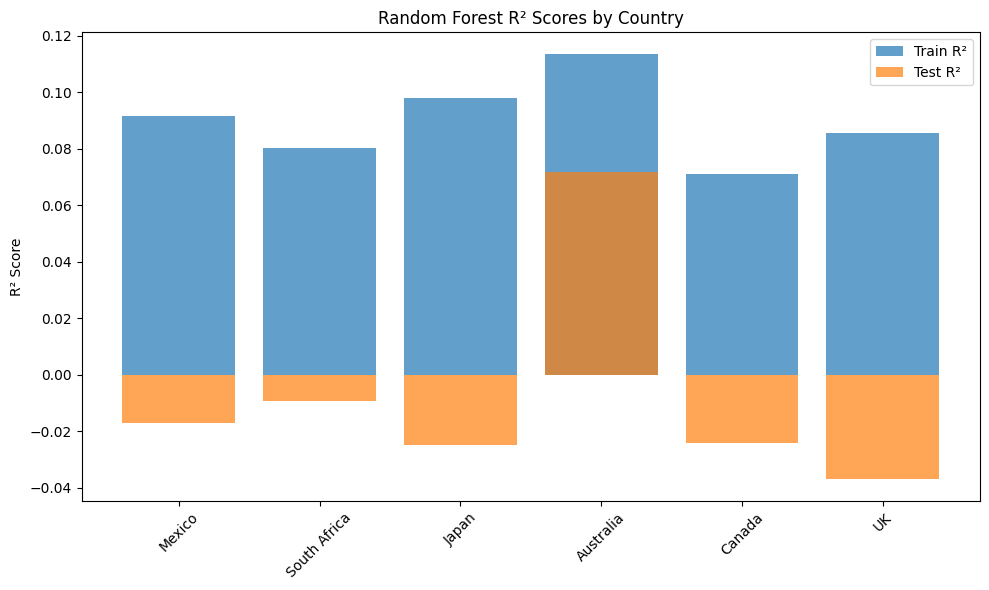

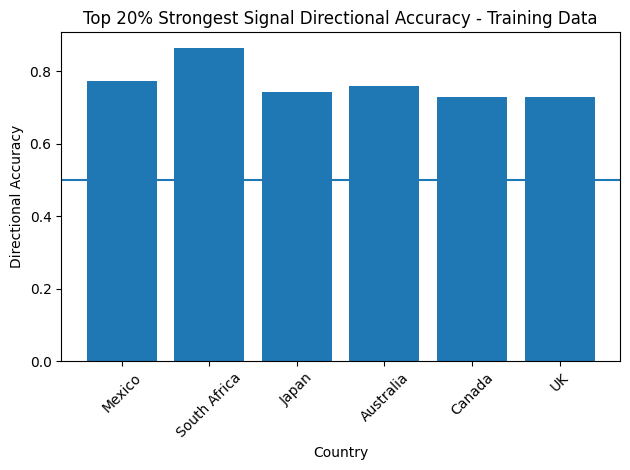

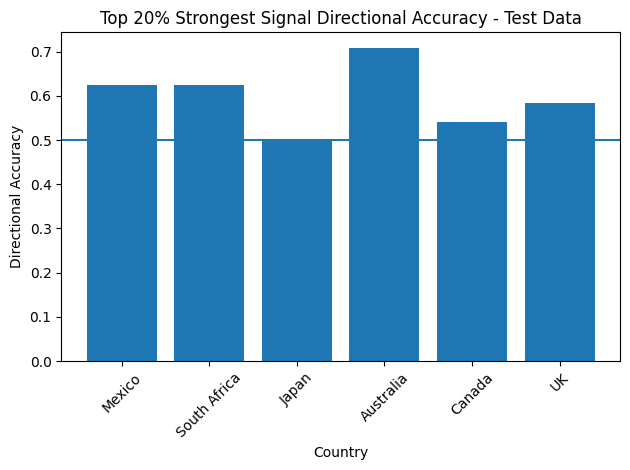

In [474]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(train_r2s.keys(), train_r2s.values(), alpha=0.7, label='Train R²')
plt.bar(test_r2s.keys(), test_r2s.values(), alpha=0.7, label='Test R²')
plt.ylabel('R² Score')
plt.title('Random Forest R² Scores by Country')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Extract countries and second value from tuple
countries2 = list(train_accuracies.keys())
values = [v[0][1] for v in train_accuracies.values()]

# Create bar plot
plt.figure()
plt.bar(countries2, values)

plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 20% Strongest Signal Directional Accuracy - Training Data")
plt.xticks(rotation=45)

# Optional benchmark line at 0.5
plt.axhline(0.5)

plt.tight_layout()
plt.show()
# Extract countries and second value from tuple
countries2 = list(test_accuracies.keys())
values = [v[0][1] for v in test_accuracies.values()]

# Create bar plot
plt.figure()
plt.bar(countries2, values)

plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 20% Strongest Signal Directional Accuracy - Test Data")
plt.xticks(rotation=45)

# Optional benchmark line at 0.5
plt.axhline(0.5)

plt.tight_layout()
plt.show()

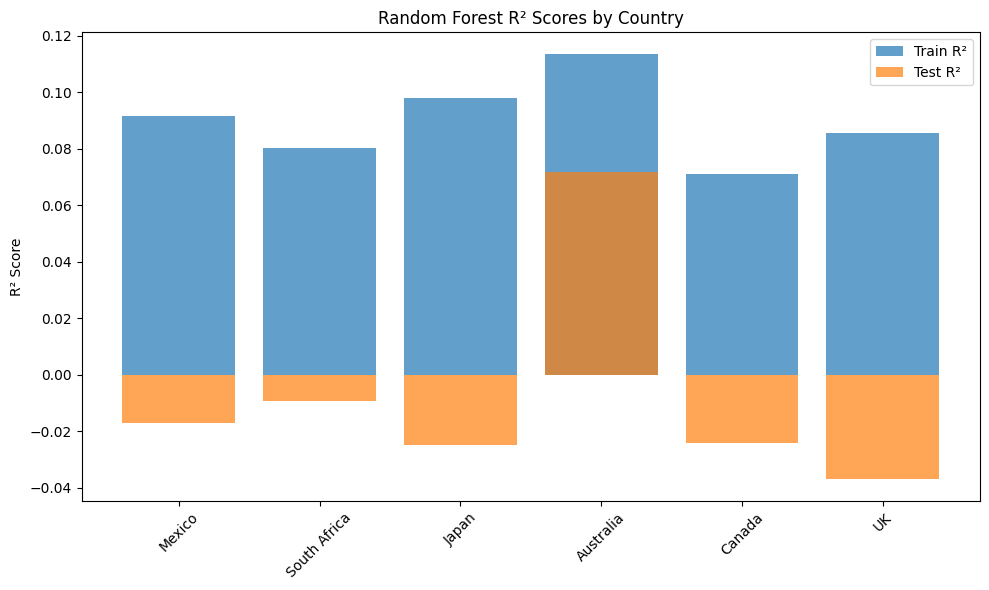

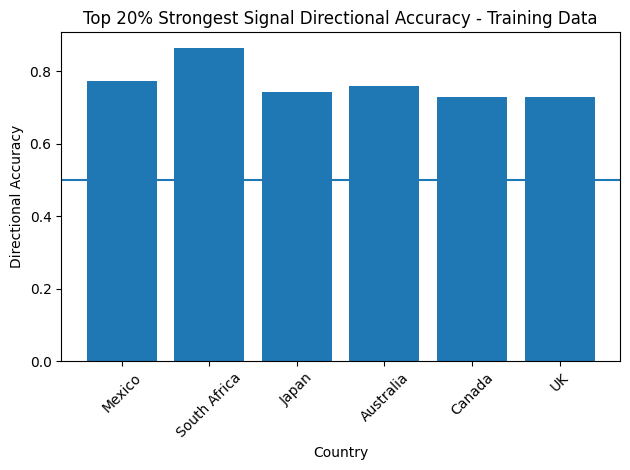

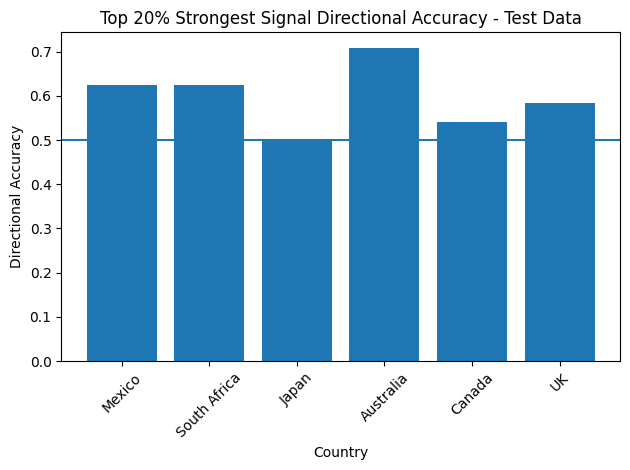

In [475]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(train_r2s.keys(), train_r2s.values(), alpha=0.7, label='Train R²')
plt.bar(test_r2s.keys(), test_r2s.values(), alpha=0.7, label='Test R²')
plt.ylabel('R² Score')
plt.title('Random Forest R² Scores by Country')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Extract countries and second value from tuple
countries2 = list(train_accuracies.keys())
values = [v[0][1] for v in train_accuracies.values()]

# Create bar plot
plt.figure()
plt.bar(countries2, values)

plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 20% Strongest Signal Directional Accuracy - Training Data")
plt.xticks(rotation=45)

# Optional benchmark line at 0.5
plt.axhline(0.5)

plt.tight_layout()
plt.show()
# Extract countries and second value from tuple
countries2 = list(test_accuracies.keys())
values = [v[0][1] for v in test_accuracies.values()]

# Create bar plot
plt.figure()
plt.bar(countries2, values)

plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 20% Strongest Signal Directional Accuracy - Test Data")
plt.xticks(rotation=45)

# Optional benchmark line at 0.5
plt.axhline(0.5)

plt.tight_layout()
plt.show()

In [476]:
preds.to_csv("../data/rf_predictions.csv")

# Try Quantiled regressions

In [477]:
country_tails = {}
for country, data in countries.items():
    print(f'{country}')
    # display(data.head())
    temp = data.copy()
    temp = temp['2022-01-01':'2026-01-01']
    country_tails[country] = temp[(temp['Excess Return_quantiles'] == 0)]
    display(country_tails[country].head())
    print(f"Proportion of extreme quantiles: {len(country_tails[country]) / len(temp):.2%}")


Mexico


KeyError: 'Excess Return_quantiles'

In [ ]:
#preds = pd.DataFrame()
train_r2s = {}
test_r2s = {}
train_accuracies = {}
test_accuracies = {}

for country, data in country_tails.items():
    if country not in country_residuals:
        print(f"Residuals for {country} not found. Skipping regression.")
        continue
    X_train = country_tails[country]['2022-01-01':'2024-09-30']
    y_train = country_residuals[country]['2022-01-01':'2024-09-30'].shift(-1).dropna()  # Shift to align with next day's return
    X_train = X_train.copy()
    y_train = y_train.copy()
    X_train.index = pd.to_datetime(X_train.index)
    y_train.index = pd.to_datetime(y_train.index)
    df_train = pd.concat([X_train, y_train], axis=1).dropna()
    df_train.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features
    

    X_test = country_tails[country]['2025-01-01':'2026-01-01']
    y_test = country_residuals[country]['2025-01-01':'2026-01-01'].shift(-1).dropna()  # Shift to align with next day's return
    X_test = X_test.copy()
    y_test = y_test.copy()
    X_test.index = pd.to_datetime(X_test.index)
    y_test.index = pd.to_datetime(y_test.index)
    df_test = pd.concat([X_test, y_test], axis=1).dropna()
    df_test.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features

    print(f"\nRandom Forest Regression Results for {country}:")
    rf_predictions, rf_model_instance ,ys, train_r2, test_r2, strong_acc_train, strong_acc_test= random_forest_model(df_train.iloc[:, :-1], df_train.iloc[:, -1], df_test.iloc[:, :-1], df_test.iloc[:, -1])
    #
    train_r2s[country] = train_r2
    test_r2s[country] = test_r2
    train_accuracies[country] = strong_acc_train
    test_accuracies[country] = strong_acc_test

    


Random Forest Regression Results for Mexico:

Importance-Based Feature Selection:
Training Data:
Train R² (Reduced): 0.14301907844635897
Overall Directional Accuracy: 0.5974025974025974
Top 100% Strongest Signals:
Directional Accuracy: 0.5974025974025974

Testing Data:
Reduced Test R²: -0.1538827995151122
Overall Directional Accuracy: 0.5833333333333334
Top 100% Strongest Signals:
Directional Accuracy: 0.5833333333333334
Residuals for Brazil not found. Skipping regression.

Random Forest Regression Results for South Africa:

Importance-Based Feature Selection:
Training Data:
Train R² (Reduced): 0.12158584885245705
Overall Directional Accuracy: 0.75
Top 100% Strongest Signals:
Directional Accuracy: 0.75

Testing Data:
Reduced Test R²: -0.02392380924798765
Overall Directional Accuracy: 0.5555555555555556
Top 100% Strongest Signals:
Directional Accuracy: 0.5555555555555556

Random Forest Regression Results for Japan:

Importance-Based Feature Selection:
Training Data:
Train R² (Reduced):